### Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

ROOT = Path("/home/lstracke/train_cifar/openmixup_cifar_training/visualization/convnext_tiny_new")

METHODS: list[str] = [
    "none",
    "grayscale",
    "color_opponency",
    "single_color",
]

SEEDS: list[int] = [7, 25, 42]



all_data_vanilla = []

all_data_mixup = []

for csv_file in ROOT.rglob(pattern="corruption_results_*.csv"):

    path_str = str(object=csv_file)

    method = None
    for m in METHODS:
        if f"/{m}/" in path_str:
            method = m
            break

    seed_match: re.Match[str] | None = re.search(r"seed_(\d+)", string=path_str)
    seed = int(seed_match.group(1))

    sparsity_match: re.Match[str] | None = re.search(
        r"seed_\d+/([0-9.]+)/",
        string=path_str
    )

    sparsity = float(sparsity_match.group(1))


    df = pd.read_csv(csv_file, usecols=["corruption", "severity", "top1"])

    # add metadata
    df["method"] = method
    df["seed"] = seed
    df["sparsity"] = sparsity

    if "vanilla" in path_str:
        df["type"] = "vanilla"
        all_data_vanilla.append(df)
    else:
        df["type"] = "mixup"
        all_data_mixup.append(df)
    
for i, df in enumerate(all_data_vanilla[:2]):
    print(f"\nDataFrame {i}")
    print(df.iloc[0])




DataFrame 0
corruption              clean
severity                    0
top1                     77.9
method        color_opponency
seed                       25
sparsity                  0.0
type                  vanilla
Name: 0, dtype: object

DataFrame 1
corruption              clean
severity                    0
top1                    77.85
method        color_opponency
seed                       25
sparsity                  0.1
type                  vanilla
Name: 0, dtype: object


In [3]:
method_order = ["none", "grayscale", "color_opponency", "single_color"]
df_vanilla = pd.concat(all_data_vanilla, ignore_index=True)

grouped_vanilla = (
    df_vanilla.groupby([
        "corruption",
        "severity",
        "method",
        "sparsity",
        "type"
    ])["top1"]
    .agg(
        mean="mean",
        std=lambda x: np.std(x, ddof=1)
    )
    .reset_index()
)
print(grouped_vanilla.head())

  corruption severity           method  sparsity     type       mean       std
0        all     mean  color_opponency       0.0  vanilla  32.593822  0.220163
1        all     mean  color_opponency       0.1  vanilla  32.580133  0.219227
2        all     mean  color_opponency       0.2  vanilla  32.564356  0.212092
3        all     mean  color_opponency       0.3  vanilla  32.427956  0.185896
4        all     mean  color_opponency       0.4  vanilla  32.039511  0.184282


In [4]:
df_mixup = pd.concat(all_data_mixup, ignore_index=True)

grouped_mixup= (
    df_mixup.groupby([
        "corruption",
        "severity",
        "method",
        "sparsity",
        "type"
    ])["top1"]
    .agg(
        mean="mean",
        std=lambda x: np.std(x, ddof=1)
    )
    .reset_index()
)

print(grouped_mixup.head())

  corruption severity           method  sparsity   type       mean       std
0        all     mean  color_opponency       0.0  mixup  32.241067  0.128366
1        all     mean  color_opponency       0.1  mixup  32.237556  0.129665
2        all     mean  color_opponency       0.2  mixup  32.223556  0.126247
3        all     mean  color_opponency       0.3  mixup  32.072400  0.110145
4        all     mean  color_opponency       0.4  mixup  31.650444  0.121055


#### mean and std from mean co 0.0 vanilla

In [5]:
x = np.array([
    32.61586666666667,
    32.80213333333333,
    32.36346666666666
])

print("mean: ", x.mean())
print("std: ", x.std(ddof=1))

mean:  32.59382222222222
std:  0.22016262003178494


### Plot data for corruption - mean

In [13]:
corruptions = [
    "clean",
    "gaussian_noise",
    "shot_noise",
    "impulse_noise",
    "defocus_blur",
    "glass_blur",
    "motion_blur",
    "zoom_blur",
    "snow",
    "frost",
    "fog",
    "brightness",
    "contrast",
    "elastic_transform",
    "pixelate",
    "jpeg_compression",
    "all"
]

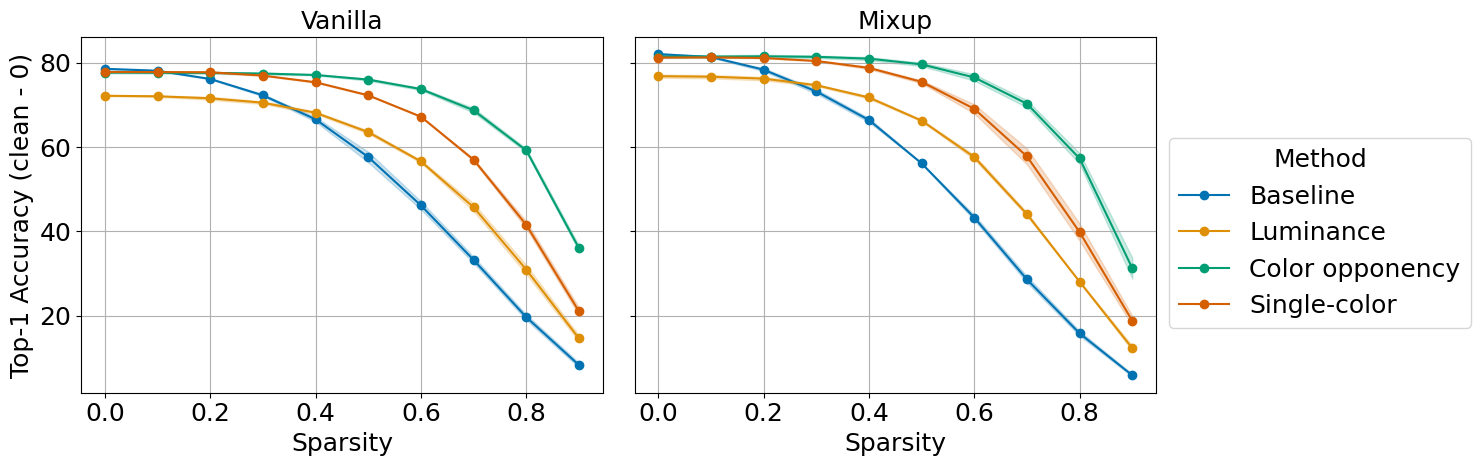

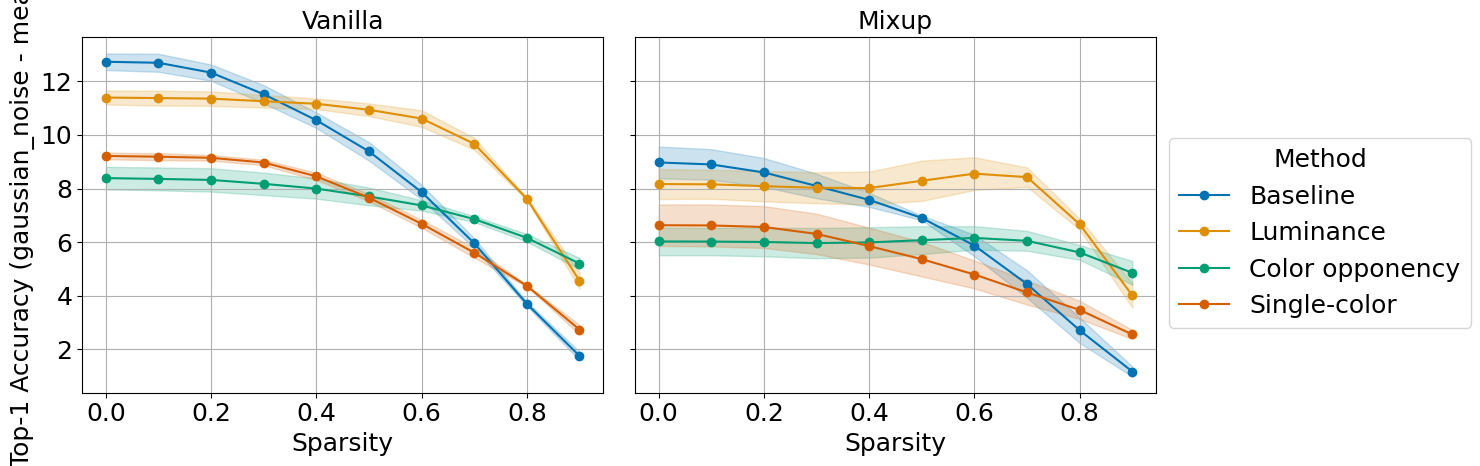

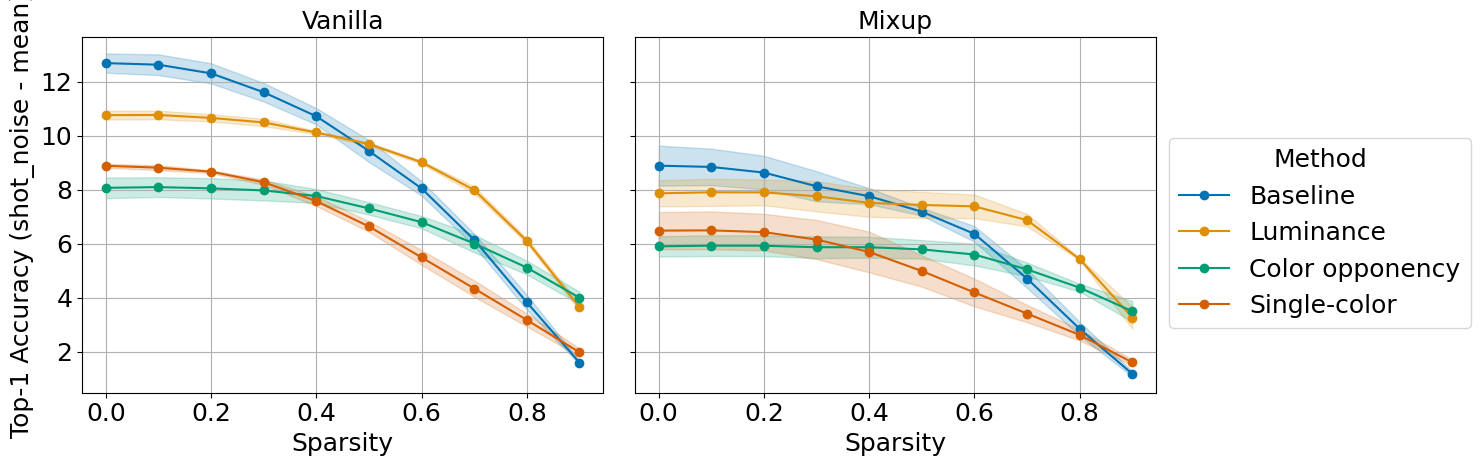

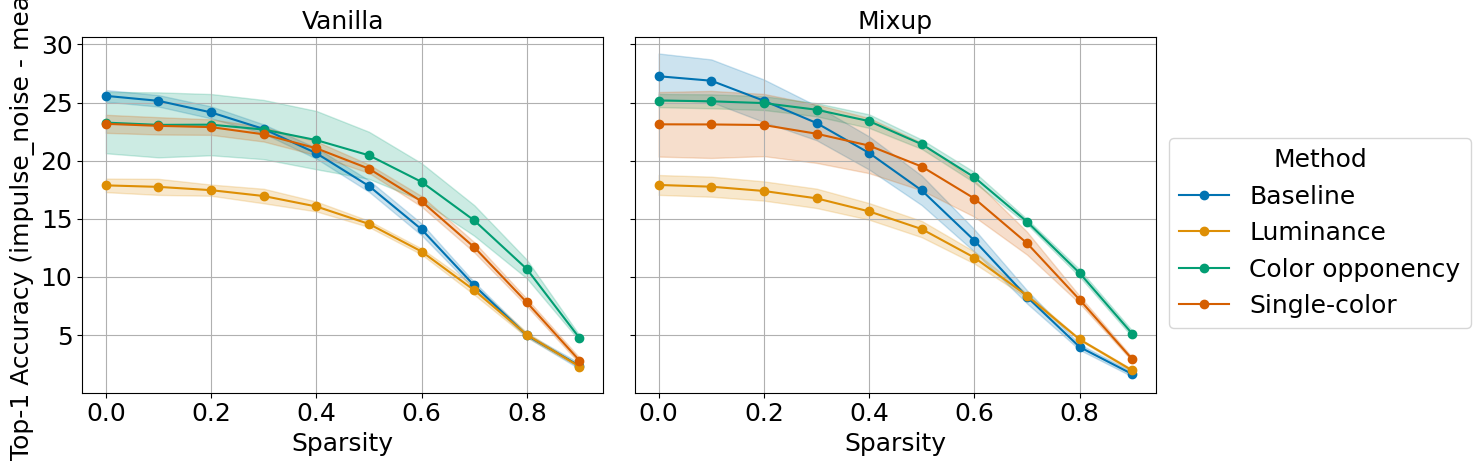

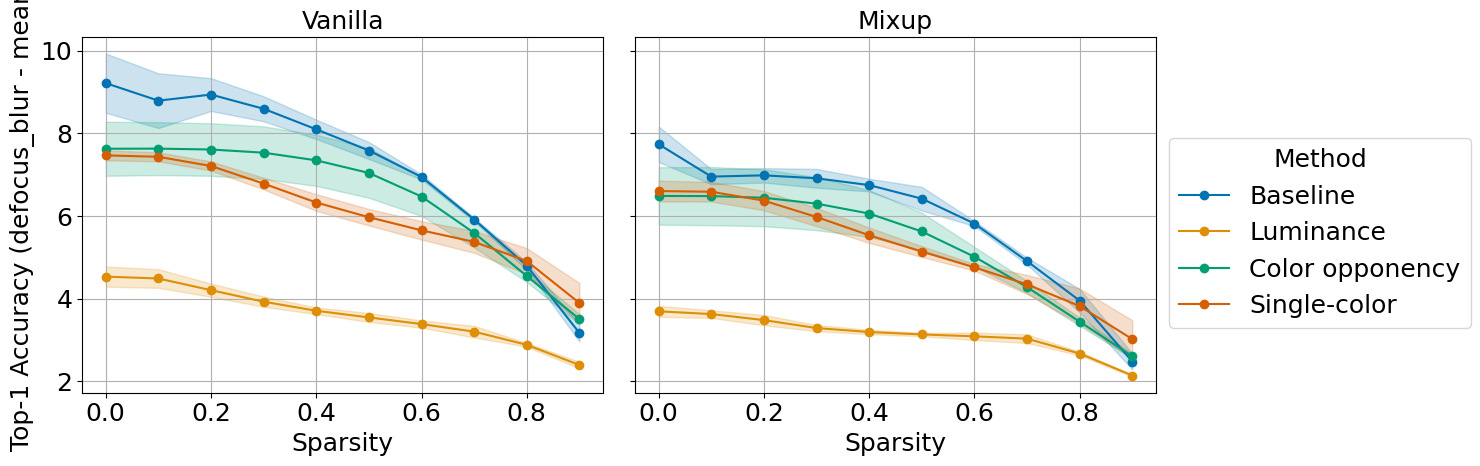

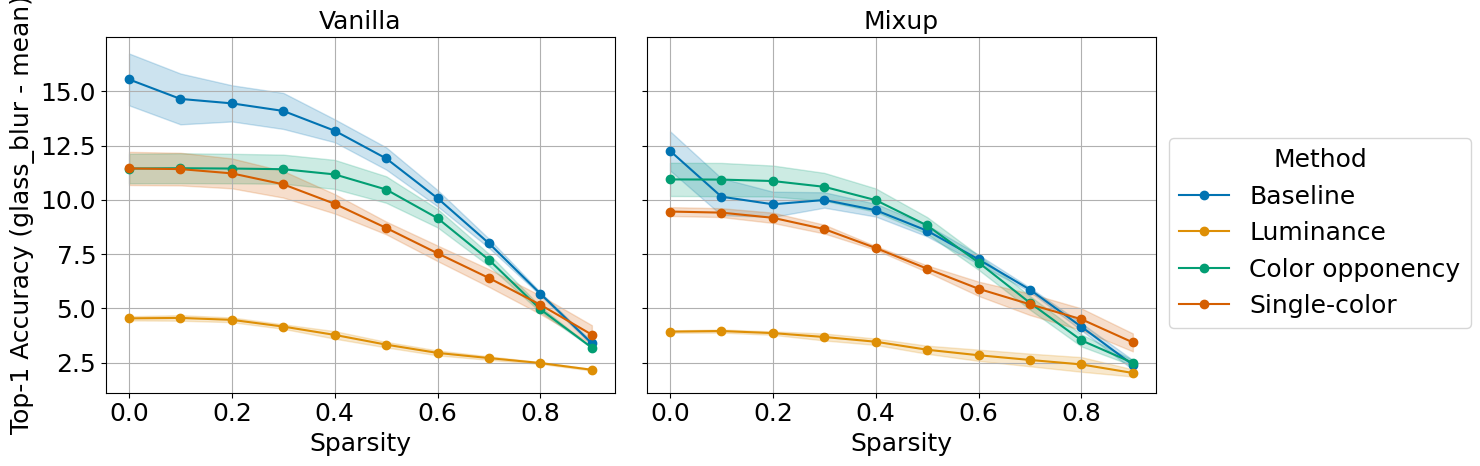

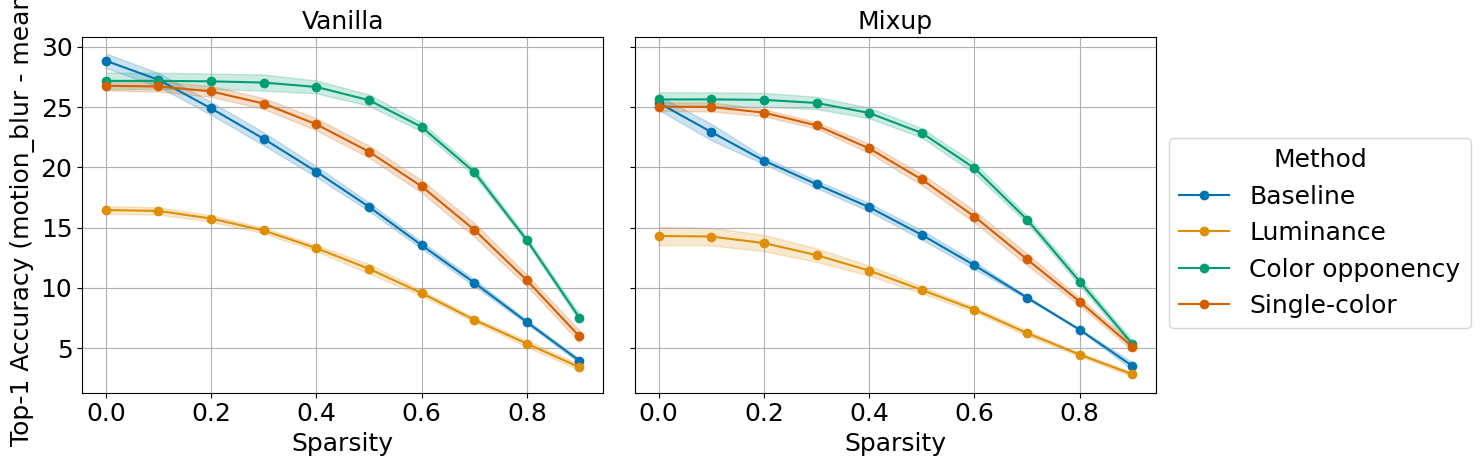

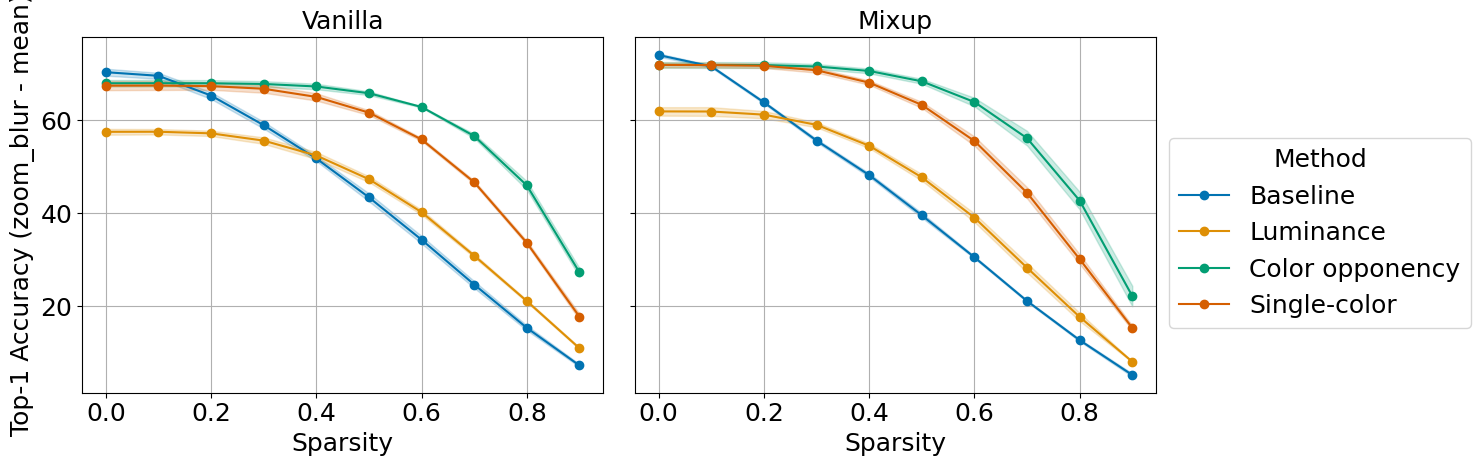

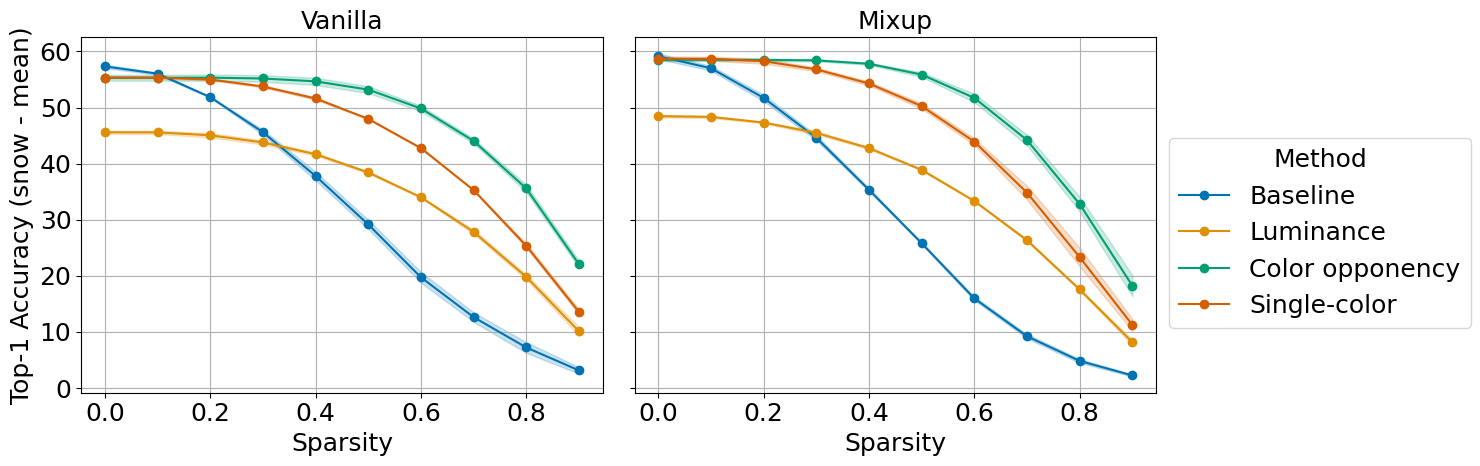

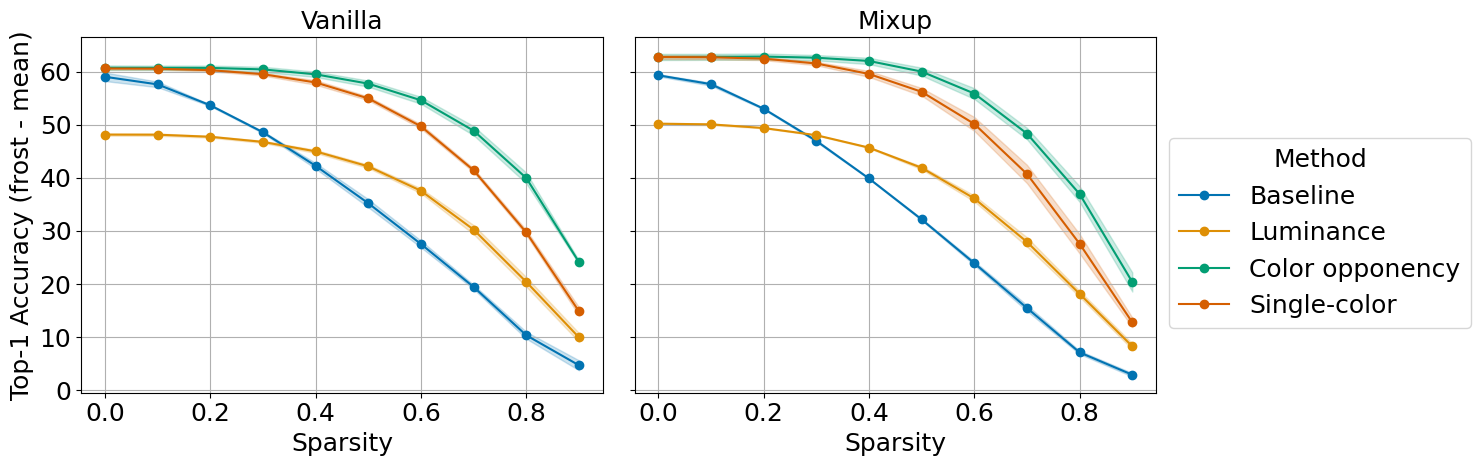

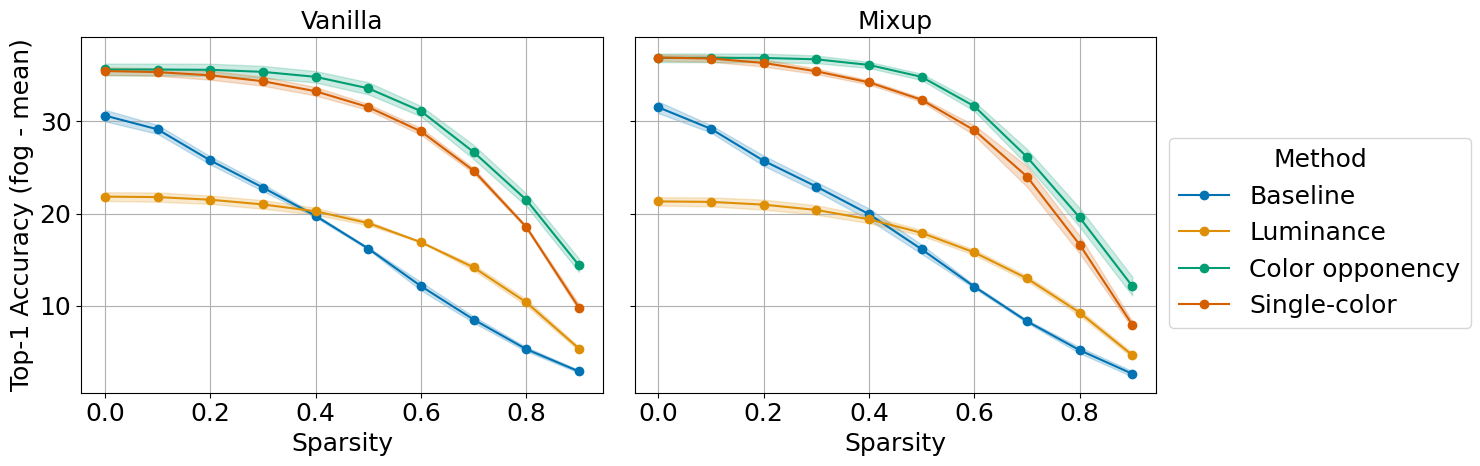

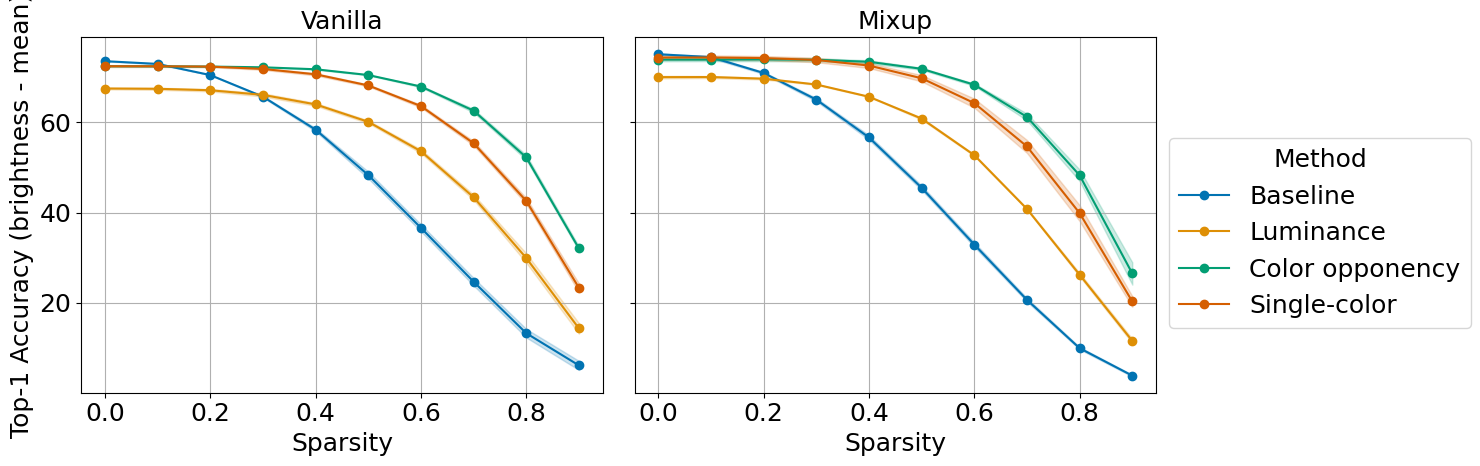

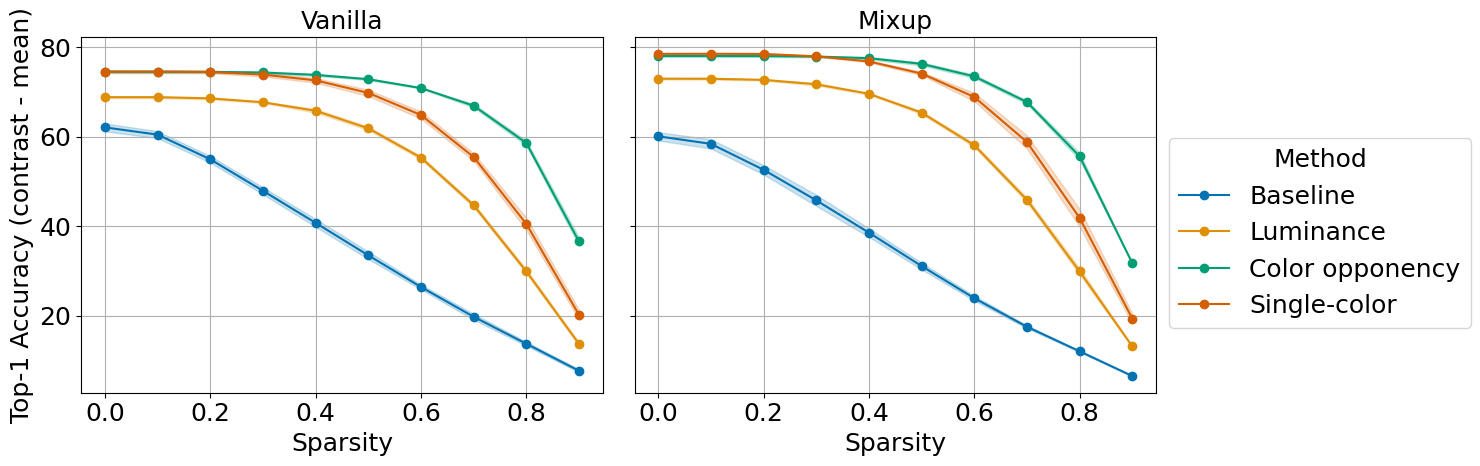

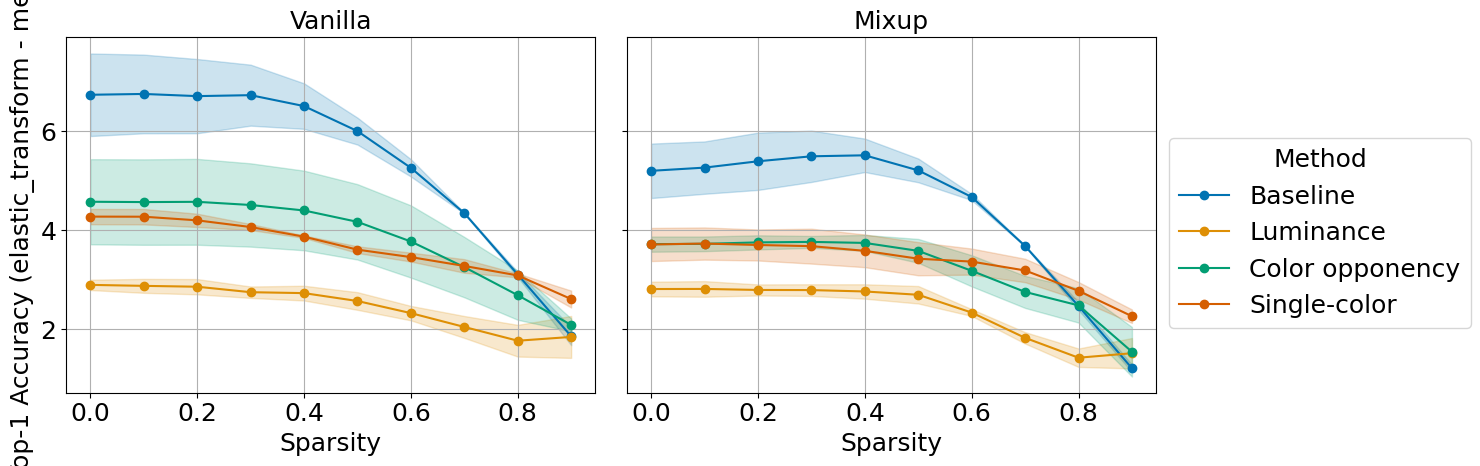

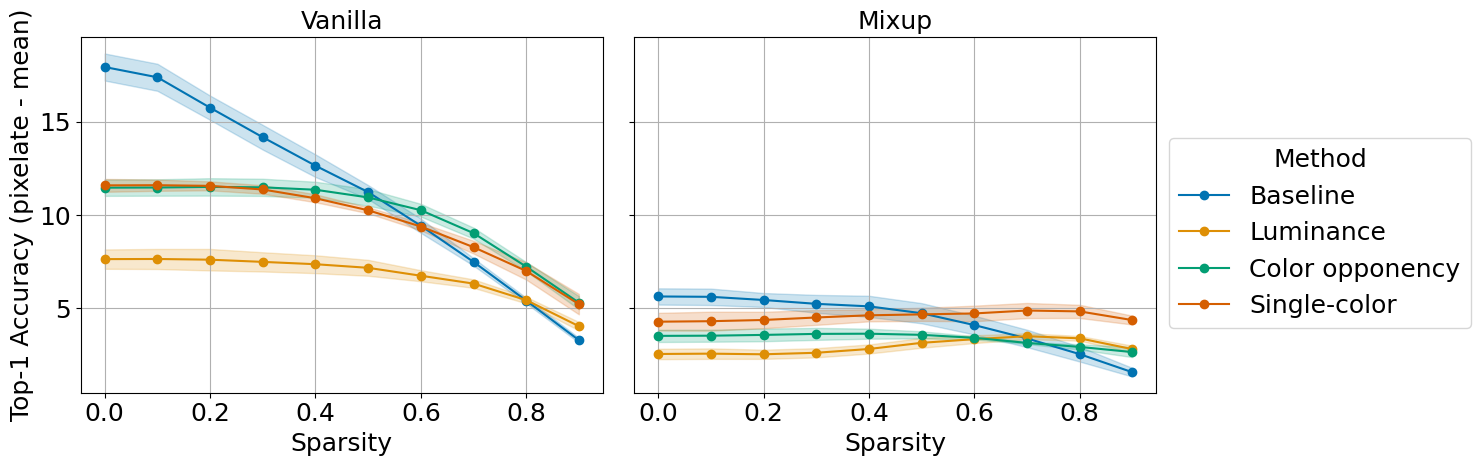

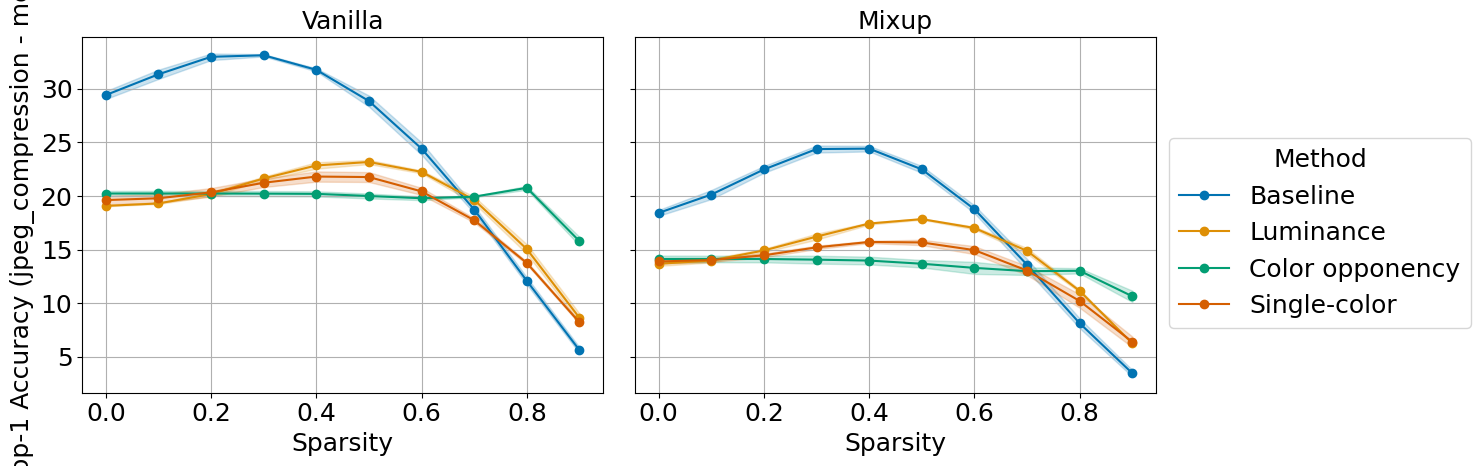

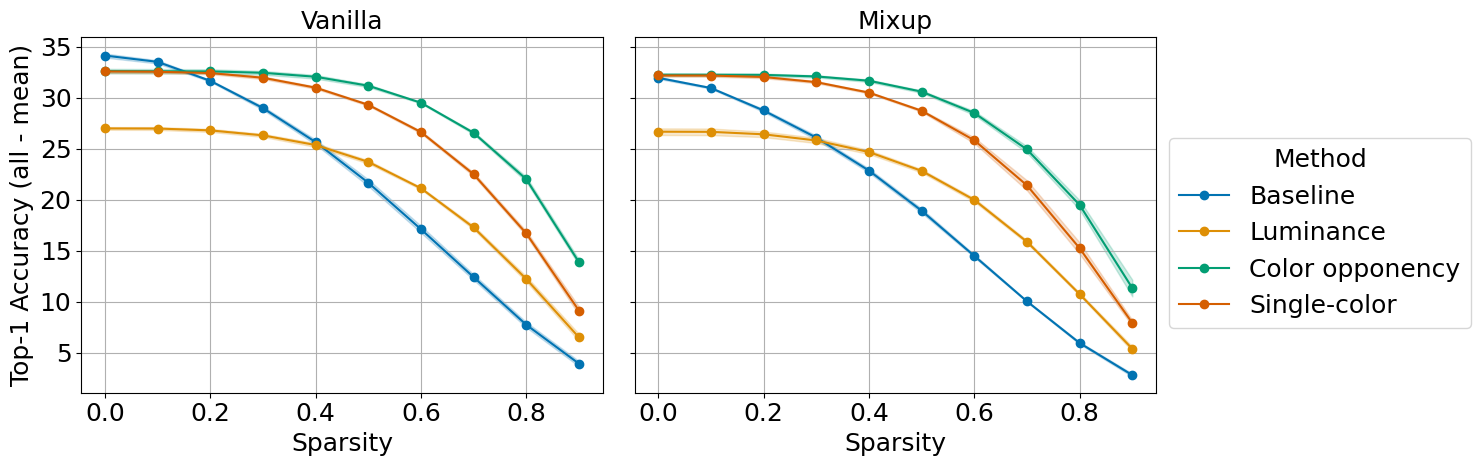

In [15]:
import seaborn as sns
palette = sns.color_palette("colorblind")
method_order = ["none", "grayscale", "color_opponency", "single_color"]
palette_map = dict(zip(method_order, palette))

label_map = {
    "none": "Baseline",
    "grayscale": "Luminance",
    "color_opponency": "Color opponency",
    "single_color": "Single-color"
}



for corruption in corruptions:
    if corruption == "clean":
        severity = "0"
    else:
        severity = "mean"
    mixup_brightness = grouped_mixup[
        (grouped_mixup["corruption"] == corruption) &
        (grouped_mixup["severity"] == severity)
    ]

    vanilla_brightness = grouped_vanilla[
        (grouped_vanilla["corruption"] == corruption) &
        (grouped_vanilla["severity"] == severity)
    ]

    mixup_brightness = (
        mixup_brightness
        .groupby(["method", "sparsity"])
        .agg(
            mean=("mean", "mean"),
            std=("std", "mean")   
        )
        .reset_index()
    )

    vanilla_brightness = (
        vanilla_brightness
        .groupby(["method", "sparsity"])
        .agg(
            mean=("mean", "mean"),
            std=("std", "mean")
        )
        .reset_index()
    )

    #print(mixup_brightness)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, data, title in zip(
        axes,
        [vanilla_brightness, mixup_brightness],
        ["Vanilla", "Mixup"]
    ):
        for method in METHODS:
            df_plot = data[data["method"] == method].sort_values("sparsity")
            #print(df_plot["mean"], df_plot["std"])

            

            ax.plot(
                df_plot["sparsity"],
                df_plot["mean"],
                marker="o",
                label=label_map[method],
                color=palette_map[method]
            )

            ax.fill_between(
                df_plot["sparsity"],
                df_plot["mean"] - df_plot["std"],
                df_plot["mean"] + df_plot["std"],
                alpha=0.2,
                color=palette_map[method]
            )

        ax.set_title(title)
        ax.set_xlabel("Sparsity")
        ax.grid(True)
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center right",
        bbox_to_anchor=(1.25, 0.5),
        frameon=True,
        title="Method"

    )

    axes[0].set_ylabel(f"Top-1 Accuracy ({corruption} - {severity})")

    plt.tight_layout()
    plt.show()

### Compare Vanilla contrast and shot noise

In [8]:
corruptions = [
    "contrast",
    "shot_noise",
]

mixup= False

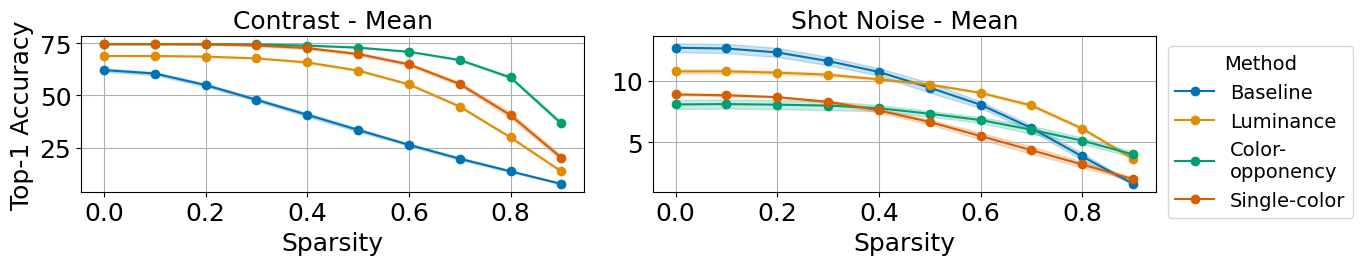

In [9]:
import seaborn as sns
palette = sns.color_palette("colorblind")
method_order = ["none", "grayscale", "color_opponency", "single_color"]
palette_map = dict(zip(method_order, palette))

label_map = {
    "none": "Baseline",
    "grayscale": "Luminance",
    "color_opponency": "Color-\nopponency",
    "single_color": "Single-color"
}

font_size = 18

plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
})

data_source = grouped_mixup if mixup else grouped_vanilla
dataset_name = "Mixup" if mixup else "Vanilla"

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

titles = ["Contrast - Mean", "Shot Noise - Mean"]

for ax, corruption, title in zip(axes, corruptions, titles):
    severity = "mean"
    df_plot = (
        data_source[
            (data_source["corruption"] == corruption) &
            (data_source["severity"] == severity)
        ]
        .groupby(["method", "sparsity"])
        .agg(
            mean=("mean", "mean"),
            std=("std", "mean")
        )
        .reset_index()
    )

    for method in METHODS:
        method_data = df_plot[df_plot["method"] == method].sort_values("sparsity")
        ax.plot(
            method_data["sparsity"],
            method_data["mean"],
            marker="o",
            label=label_map[method],
            color=palette_map[method]
        )
        ax.fill_between(
            method_data["sparsity"],
            method_data["mean"] - method_data["std"],
            method_data["mean"] + method_data["std"],
            alpha=0.2,
            color=palette_map[method]
        )

    ax.set_title(title, fontsize=font_size)
    ax.set_xlabel("Sparsity", fontsize=font_size)
    ax.tick_params(axis='both', labelsize=font_size)
    ax.grid(True)

axes[0].set_ylabel("Top-1 Accuracy", fontsize=font_size)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.15, 0.5),
    frameon=True,
    title="Method",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()